# Advanced Lung Cancer Detection using Transfer Learning

## Using ResNet50, EfficientNet, Data Augmentation, and Advanced Evaluation Techniques

This notebook implements state-of-the-art techniques for medical image classification:
- Transfer Learning with pre-trained models
- Advanced data augmentation
- Focal Loss for class imbalance
- K-Fold Cross-Validation
- ROC-AUC curves and confusion matrices
- Grad-CAM visualization
- Ensemble methods

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Sklearn for evaluation
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.21.0
GPU Available: []


## 2. Data Loading and Exploration

lung_n: 800 images
lung_aca: 800 images
lung_scc: 800 images


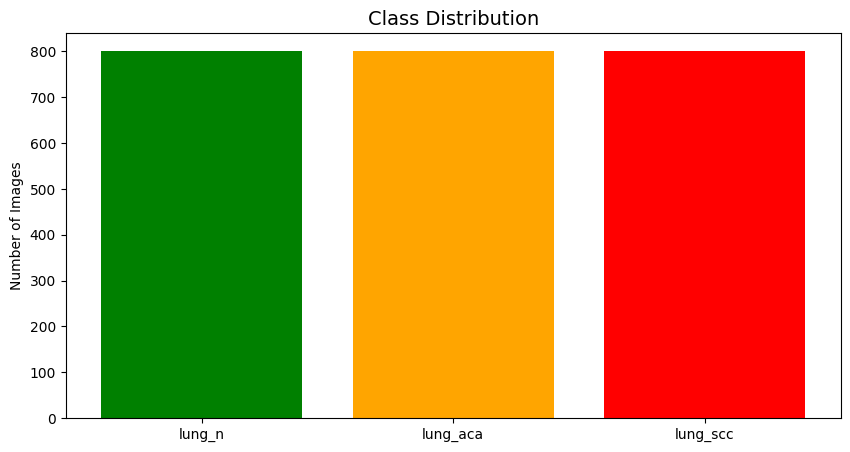


Class Weights for handling imbalance: {0: 1.0, 1: 1.0, 2: 1.0}


In [4]:
# Load data
path = 'lung_subset_small'
classes = ['lung_n', 'lung_aca', 'lung_scc']

# Count images per class
class_counts = {}
for cat in classes:
    image_dir = f'{path}/{cat}'
    image_count = len(os.listdir(image_dir))
    class_counts[cat] = image_count
    print(f'{cat}: {image_count} images')

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['green', 'orange', 'red'])
plt.title('Class Distribution', fontsize=14)
plt.ylabel('Number of Images')
plt.show()

# Check for class imbalance
total_images = sum(class_counts.values())
class_weights = {i: total_images / (len(classes) * count) for i, count in enumerate(class_counts.values())}
print(f'\nClass Weights for handling imbalance: {class_weights}')

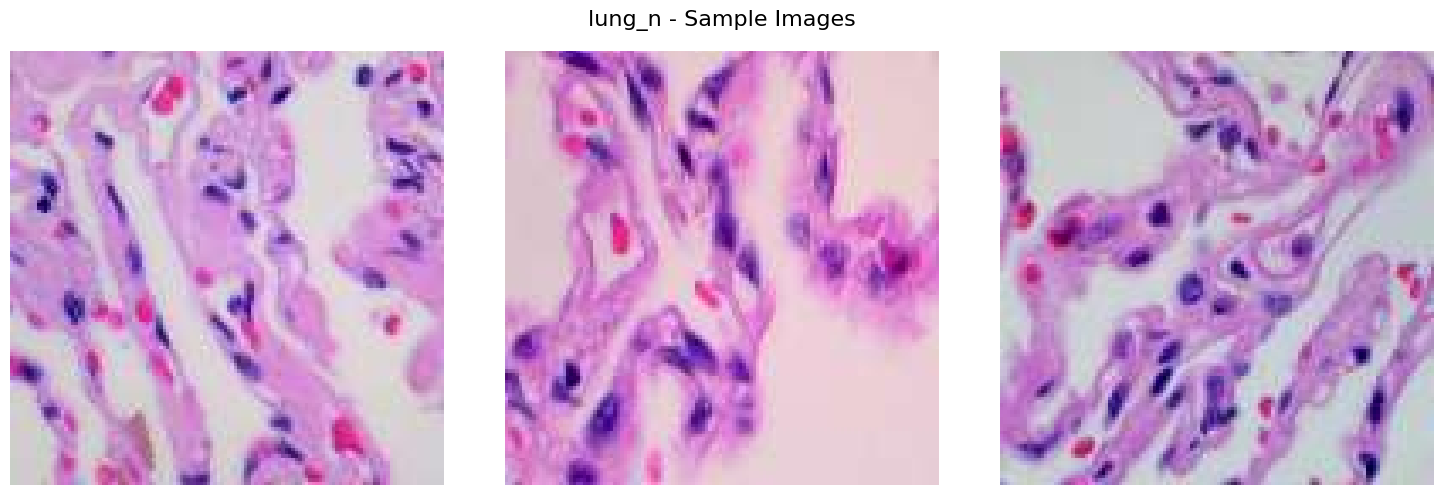

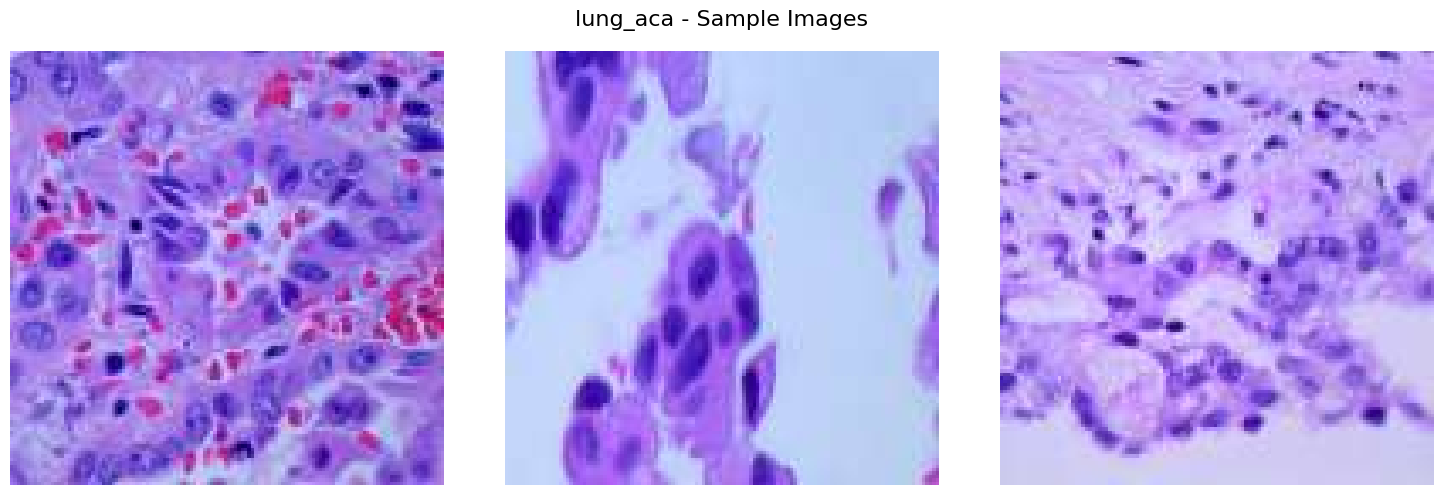

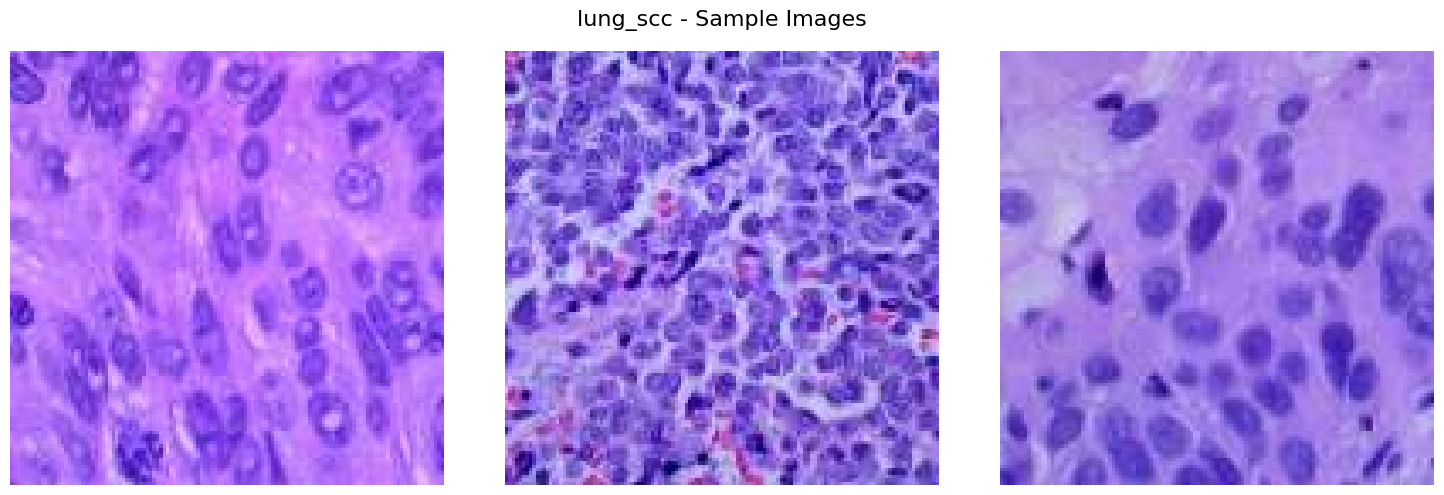

In [5]:
# Visualize sample images from each class
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{cat} - Sample Images', fontsize=16)
    
    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()

## 3. Data Preprocessing with Advanced Augmentation

In [7]:
# Configuration
IMG_SIZE = 224  # Larger size for better feature extraction
BATCH_SIZE = 32
EPOCHS = 30

# Advanced Data Augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2
)

# Validation data augmentation (minimal - only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with augmentation
train_data = train_datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Class indices: {train_data.class_indices}")

Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.
Training samples: 1920
Validation samples: 480
Class indices: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


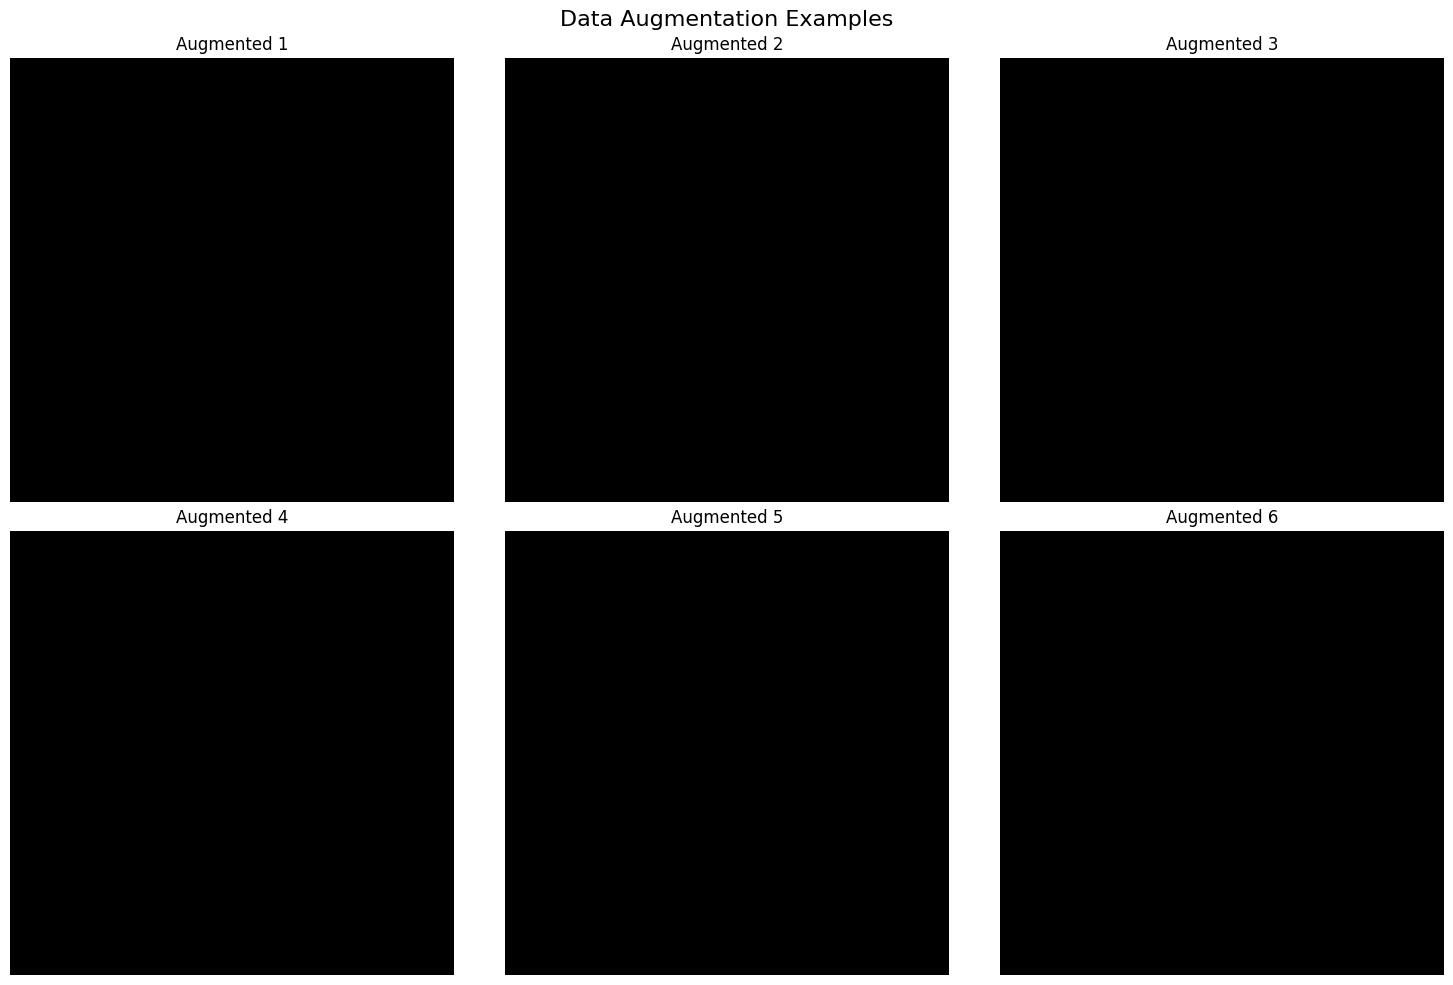

In [8]:
# Visualize augmented images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Data Augmentation Examples', fontsize=16)

augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Get a sample image
sample_image_path = f'{path}/lung_n/{os.listdir(f"{path}/lung_n")[0]}'
sample_image = Image.open(sample_image_path)
sample_array = np.array(sample_image).reshape((1,) + np.array(sample_image).shape) / 255.0

# Generate augmented versions
for i in range(6):
    aug_iter = augmented_datagen.flow(sample_array, batch_size=1)
    aug_image = next(aug_iter)[0]
    ax[i//3, i%3].imshow(aug_image)
    ax[i//3, i%3].axis('off')
    ax[i//3, i%3].set_title(f'Augmented {i+1}')

plt.tight_layout()
plt.show()

## 4. Focal Loss - Handling Class Imbalance

In [9]:
# Implement Focal Loss for better handling of class imbalance
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss for addressing class imbalance
    gamma: focusing parameter (higher = more focus on hard examples)
    alpha: weighting factor for rare class
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        ce_loss = -y_true * tf.math.log(y_pred)
        focal_weight = tf.pow(1. - y_pred, gamma)
        focal_loss_val = alpha * focal_weight * ce_loss
        
        return tf.reduce_mean(tf.reduce_sum(focal_loss_val, axis=-1))
    
    return focal_loss_fixed

print('Focal Loss defined successfully!')

Focal Loss defined successfully!


## 5. Transfer Learning Models

In [10]:
# Model 1: ResNet50 with Transfer Learning
def create_resnet50_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False  # Freeze base model weights
    
    model = keras.models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    
    return model, base_model

print('ResNet50 model builder created')

ResNet50 model builder created


In [11]:
# Model 2: EfficientNetB0 with Transfer Learning
def create_efficientnet_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    
    model = keras.models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    
    return model, base_model

print('EfficientNetB0 model builder created')

EfficientNetB0 model builder created


In [12]:
# Model 3: DenseNet121 with Transfer Learning
def create_densenet_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    
    model = keras.models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    
    return model, base_model

print('DenseNet121 model builder created')

DenseNet121 model builder created


## 6. Training ResNet50 Model

In [13]:
# Create and compile ResNet50 model
resnet_model, resnet_base = create_resnet50_model()

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('ResNet50 Model Summary:')
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,971 (94.50 MB)

 Trainable params: 1,182,723 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [14]:
# Callbacks for ResNet50
callbacks_resnet = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('resnet50_best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train ResNet50
print('Training ResNet50 Model...')
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks_resnet,
    class_weight=class_weights,
    verbose=1
)

print('ResNet50 Training Complete!')

Training ResNet50 Model...
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.5679 - loss: 1.1620
Epoch 1: val_accuracy improved from None to 0.34792, saving model to resnet50_best_model.h5



Epoch 1: finished saving model to resnet50_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 836ms/step - accuracy: 0.6276 - loss: 0.9518 - val_accuracy: 0.3479 - val_loss: 1.2542 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.7165 - loss: 0.6742
Epoch 2: val_accuracy did not improve from 0.34792
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 836ms/step - accuracy: 0.7089 - loss: 0.6790 - val_accuracy: 0.3333 - val_loss: 1.0653 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.7461 - loss: 0.6272
Epoch 3: val_accuracy improved from 0.34792 to 0.35625, saving model to resnet50_best_model.h5



Epoch 3: finished saving model to resnet50_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 899ms/step - accuracy: 0.7391 - loss: 0.6284 - val_accuracy: 0.3562 - val_loss: 1.1420 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.7575 - loss: 0.5747
Epoch 4: val_accuracy did not improve from 0.35625
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 821ms/step - accuracy: 0.7599 - loss: 0.5663 - val_accuracy: 0.3333 - val_loss: 3.2251 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.7308 - loss: 0.6474
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy improved from 0.35625 to 0.45208, saving model to resnet50_best_model.h5



Epoch 5: finished saving model to resnet50_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 52s 874ms/step - accuracy: 0.7448 - loss: 0.5941 - val_accuracy: 0.4521 - val_loss: 1.7037 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7694 - loss: 0.5422
Epoch 6: val_accuracy improved from 0.45208 to 0.60000, saving model to resnet50_best_model.h5



Epoch 6: finished saving model to resnet50_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 897ms/step - accuracy: 0.7604 - loss: 0.5452 - val_accuracy: 0.6000 - val_loss: 0.7408 - learning_rate: 5.0000e-04
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.7797 - loss: 0.5056
Epoch 7: val_accuracy improved from 0.60000 to 0.71250, saving model to resnet50_best_model.h5



Epoch 7: finished saving model to resnet50_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7708 - loss: 0.5288 - val_accuracy: 0.7125 - val_loss: 0.6200 - learning_rate: 5.0000e-04
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.7863 - loss: 0.5118
Epoch 8: val_accuracy did not improve from 0.71250
60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 932ms/step - accuracy: 0.7797 - loss: 0.5161 - val_accuracy: 0.6583 - val_loss: 1.0030 - learning_rate: 5.0000e-04
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.7971 - loss: 0.4759
Epoch 9: val_accuracy did not improve from 0.71250
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 843ms/step - accuracy: 0.7906 - loss: 0.4922 - val_accuracy: 0.3375 - val_loss: 3.4545 - learning_rate: 5.0000e-04
Epoch 10/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7818 - loss: 0.5198
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_accuracy did not improve from 0.71250
60/60 ━━━━━━━━━━

## 7. Training EfficientNet Model

In [15]:
# Reload validation data
val_data_eff = train_datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Create and compile EfficientNet model
efficientnet_model, efficientnet_base = create_efficientnet_model()

efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),  # Using Focal Loss
    metrics=['accuracy']
)

print('EfficientNet Model Summary:')
efficientnet_model.summary()

Found 480 images belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNet Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,326 (16.83 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

In [16]:
# Callbacks for EfficientNet
callbacks_eff = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('efficientnet_best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train EfficientNet
print('Training EfficientNet Model...')
history_eff = efficientnet_model.fit(
    train_data,
    validation_data=val_data_eff,
    epochs=EPOCHS,
    callbacks=callbacks_eff,
    class_weight=class_weights,
    verbose=1
)

print('EfficientNet Training Complete!')

Training EfficientNet Model...
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3275 - loss: 0.2658
Epoch 1: val_accuracy improved from None to 0.33333, saving model to efficientnet_best_model.h5



Epoch 1: finished saving model to efficientnet_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 509ms/step - accuracy: 0.3391 - loss: 0.2364 - val_accuracy: 0.3333 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3630 - loss: 0.2012
Epoch 2: val_accuracy did not improve from 0.33333
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 484ms/step - accuracy: 0.3417 - loss: 0.1948 - val_accuracy: 0.3333 - val_loss: 0.1369 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3025 - loss: 0.1887
Epoch 3: val_accuracy did not improve from 0.33333
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 487ms/step - accuracy: 0.3245 - loss: 0.1729 - val_accuracy: 0.3333 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.3738 - loss: 0.1644
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.33333
60/60 ━━━━━━━━━━━━━━━━━━


Epoch 5: finished saving model to efficientnet_best_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 536ms/step - accuracy: 0.3365 - loss: 0.1624 - val_accuracy: 0.3688 - val_loss: 0.1222 - learning_rate: 5.0000e-04
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.3578 - loss: 0.1551
Epoch 6: val_accuracy did not improve from 0.36875
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 481ms/step - accuracy: 0.3557 - loss: 0.1514 - val_accuracy: 0.3333 - val_loss: 0.1193 - learning_rate: 5.0000e-04
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.3715 - loss: 0.1494
Epoch 7: val_accuracy did not improve from 0.36875
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 478ms/step - accuracy: 0.3734 - loss: 0.1489 - val_accuracy: 0.3333 - val_loss: 0.1268 - learning_rate: 5.0000e-04
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3724 - loss: 0.1461
Epoch 8: val_accuracy did not improve from 0.36875
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step - accuracy: 0.3724 - loss: 0.1444 - val_accurac

## 8. Training Comparison Plots

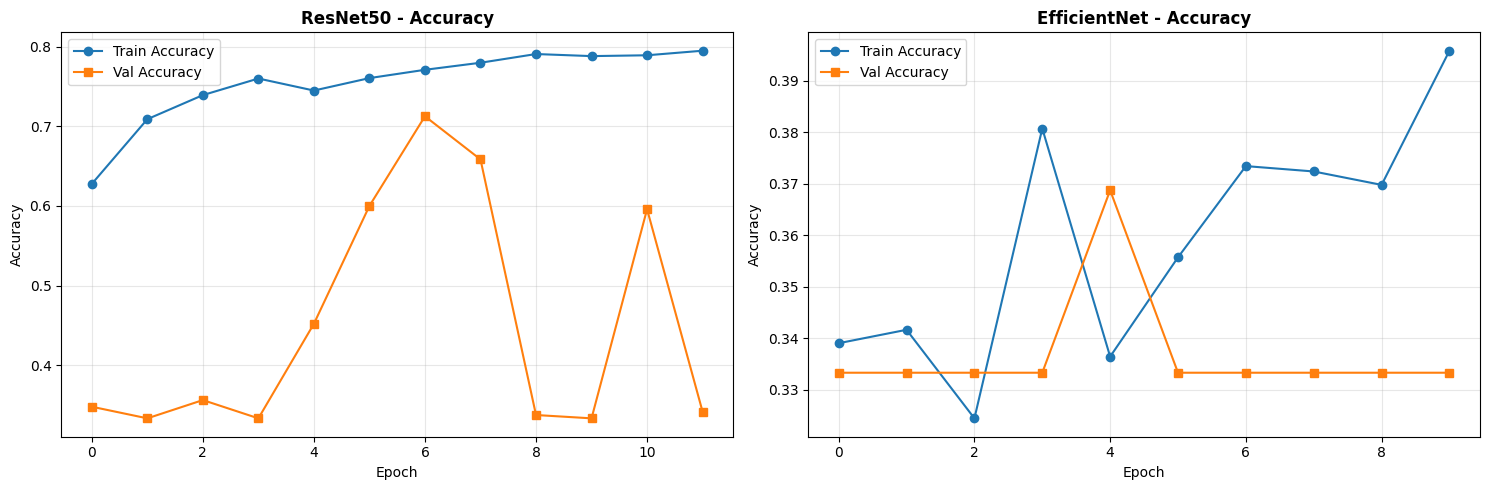

In [17]:
# Plot training histories comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ResNet50 History
axes[0].plot(history_resnet.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_resnet.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('ResNet50 - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# EfficientNet History
axes[1].plot(history_eff.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history_eff.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_title('EfficientNet - Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Advanced Evaluation - ROC-AUC Curves

In [18]:
# Prepare validation data for evaluation
val_data_eval = train_datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Get predictions for both models
y_true = val_data_eval.classes
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# ResNet50 predictions
y_pred_resnet = resnet_model.predict(val_data_eval, verbose=0)

# Reload and get EfficientNet predictions
val_data_eval2 = train_datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_pred_eff = efficientnet_model.predict(val_data_eval2, verbose=0)

print('Predictions generated')

Found 480 images belonging to 3 classes.
Found 480 images belonging to 3 classes.
Predictions generated


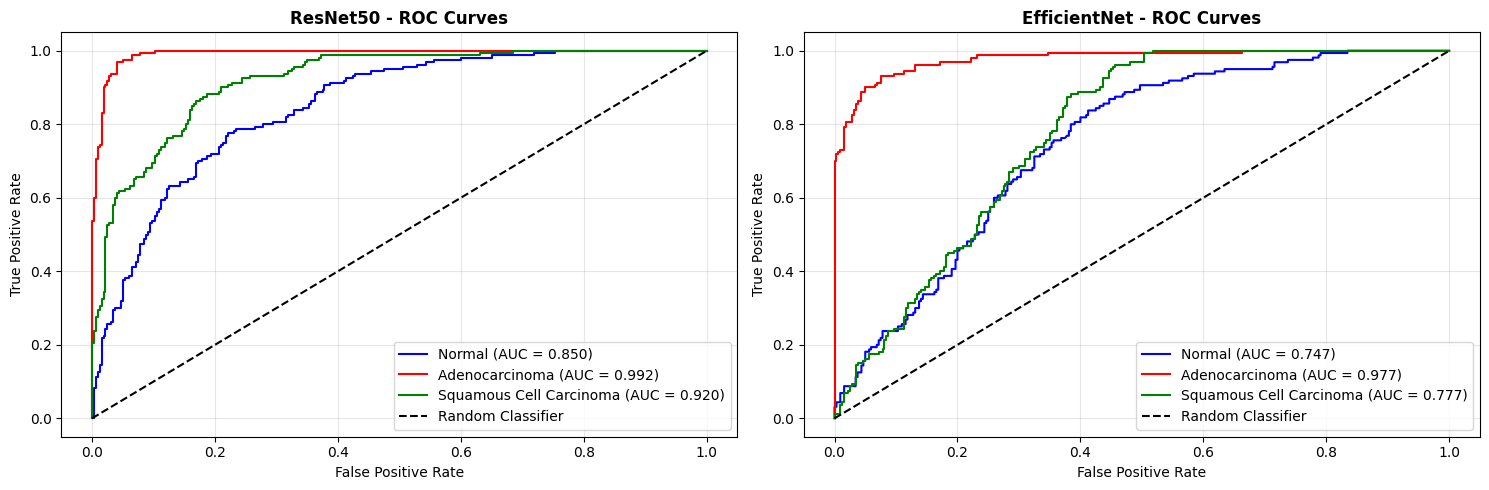

In [19]:
# Plot ROC Curves for both models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['blue', 'red', 'green']
class_names = ['Normal', 'Adenocarcinoma', 'Squamous Cell Carcinoma']

# ResNet50 ROC Curves
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_resnet[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_title('ResNet50 - ROC Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# EfficientNet ROC Curves
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_eff[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title('EfficientNet - ROC Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Confusion Matrices

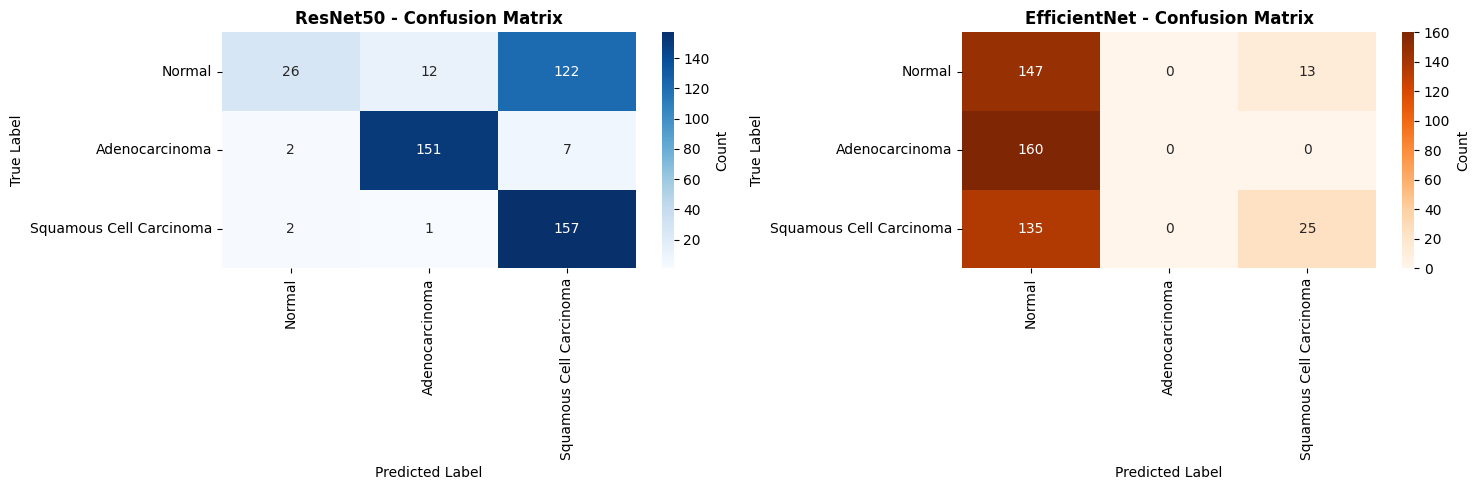

In [20]:
# Get predicted classes
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)
y_pred_eff_classes = np.argmax(y_pred_eff, axis=1)

# Create confusion matrices
cm_resnet = confusion_matrix(y_true, y_pred_resnet_classes)
cm_eff = confusion_matrix(y_true, y_pred_eff_classes)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ResNet50 Confusion Matrix
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
axes[0].set_title('ResNet50 - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# EfficientNet Confusion Matrix
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
axes[1].set_title('EfficientNet - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 11. Detailed Classification Reports

In [21]:
print('=== ResNet50 Classification Report ===')
print(classification_report(y_true, y_pred_resnet_classes, target_names=class_names))

print('\n=== EfficientNet Classification Report ===')
print(classification_report(y_true, y_pred_eff_classes, target_names=class_names))

=== ResNet50 Classification Report ===
                         precision    recall  f1-score   support

                 Normal       0.87      0.16      0.27       160
         Adenocarcinoma       0.92      0.94      0.93       160
Squamous Cell Carcinoma       0.55      0.98      0.70       160

               accuracy                           0.70       480
              macro avg       0.78      0.70      0.64       480
           weighted avg       0.78      0.70      0.64       480


=== EfficientNet Classification Report ===
                         precision    recall  f1-score   support

                 Normal       0.33      0.92      0.49       160
         Adenocarcinoma       0.00      0.00      0.00       160
Squamous Cell Carcinoma       0.66      0.16      0.25       160

               accuracy                           0.36       480
              macro avg       0.33      0.36      0.25       480
           weighted avg       0.33      0.36      0.25       480



## 12. Grad-CAM Visualization

In [22]:
def get_grad_cam(model, img_array, layer_name):
    """
    Generate Grad-CAM visualization for model predictions
    """
    # Create a model that outputs the last conv layer and predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = np.argmax(predictions[0])
        class_loss = predictions[:, class_channel]
    
    # Compute gradients
    grads = tape.gradient(class_loss, conv_outputs)
    
    # Average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply feature maps by gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Apply ReLU
    heatmap = tf.nn.relu(heatmap)
    heatmap /= tf.math.reduce_max(heatmap)
    
    return heatmap, predictions

print('Grad-CAM function defined')

Grad-CAM function defined


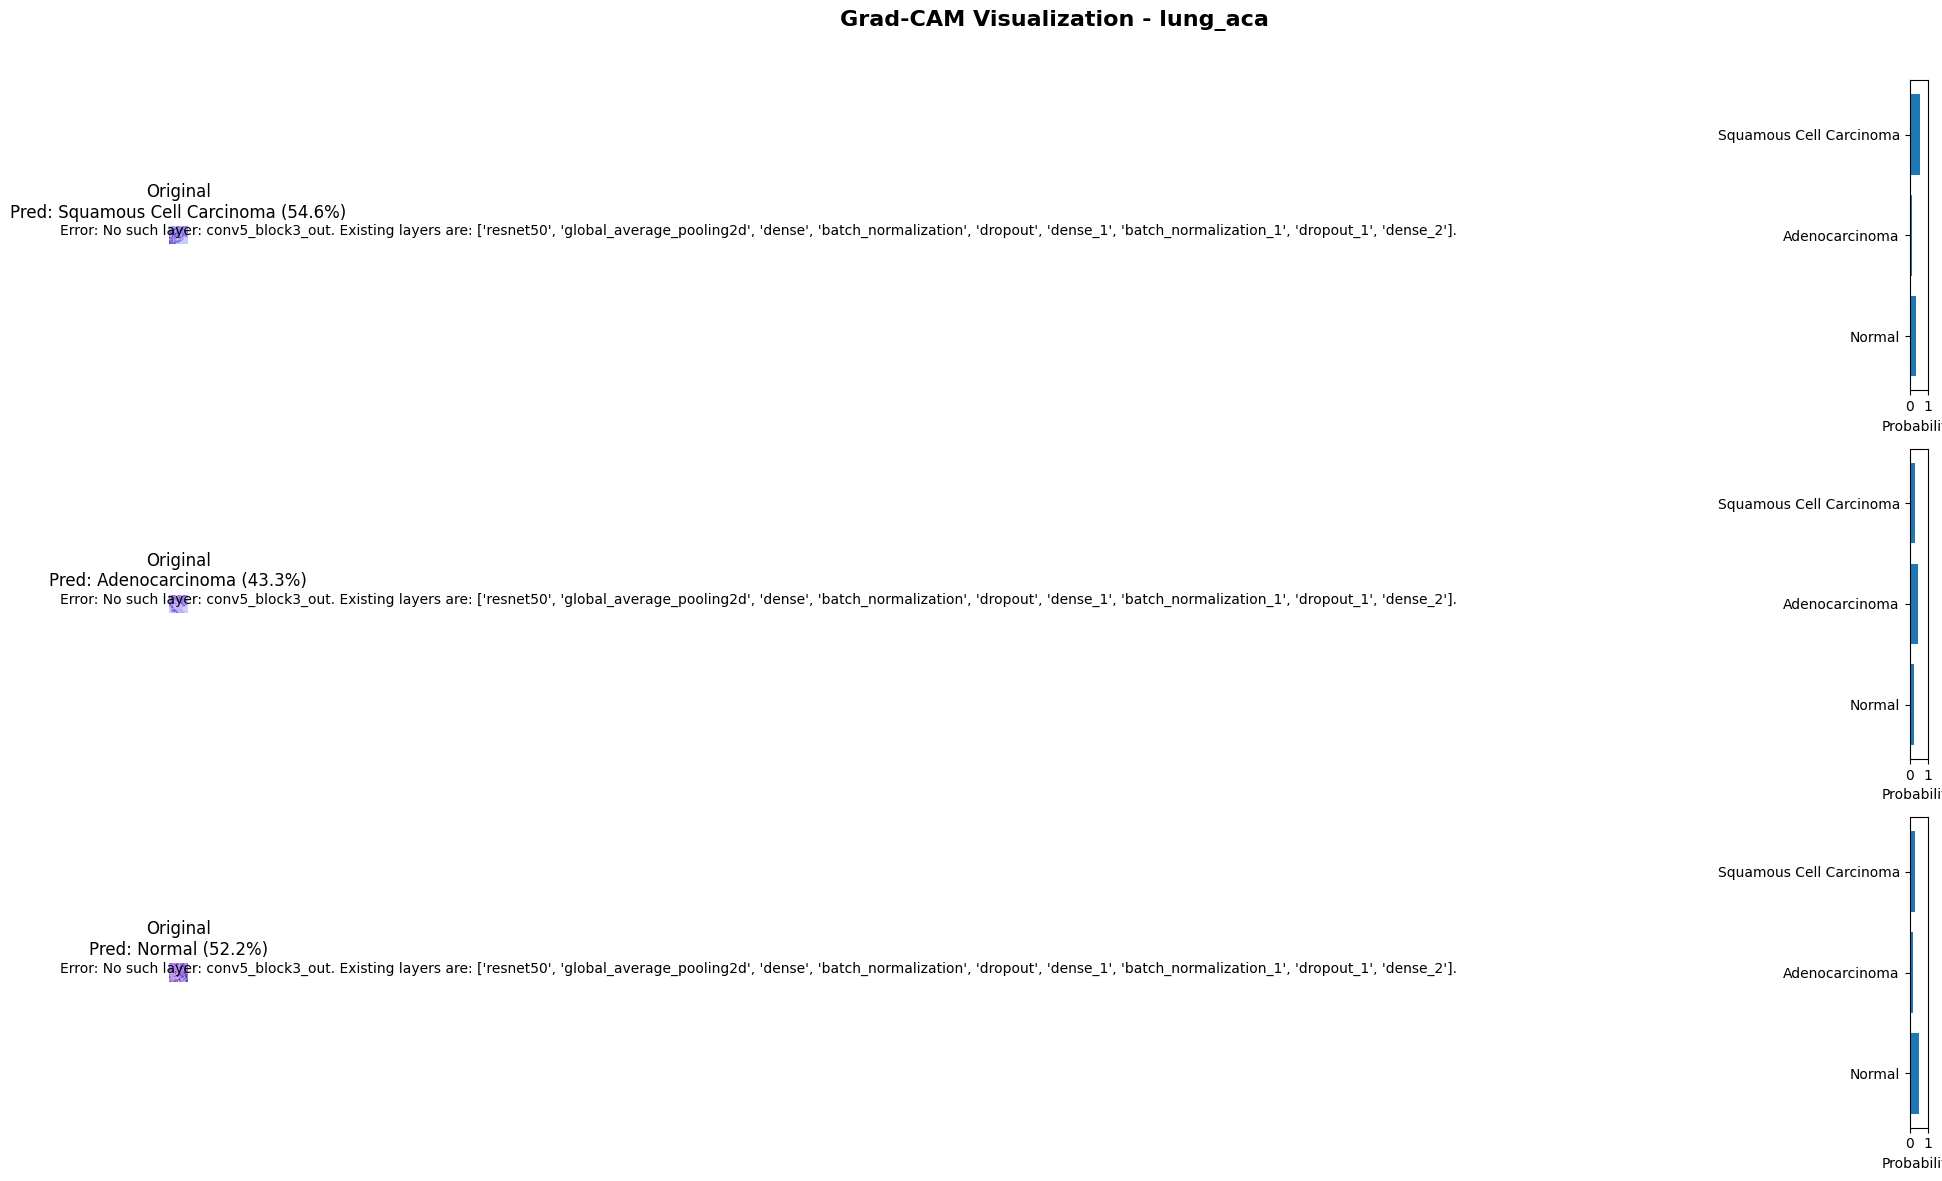

In [23]:
# Load test images and visualize Grad-CAM
test_class = 'lung_aca'
test_images = os.listdir(f'{path}/{test_class}')[:3]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle(f'Grad-CAM Visualization - {test_class}', fontsize=16, fontweight='bold')

for idx, img_name in enumerate(test_images):
    # Load image
    img_path = f'{path}/{test_class}/{img_name}'
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Get predictions
    pred = resnet_model.predict(img_batch, verbose=0)
    pred_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100
    
    # Original image
    axes[idx, 0].imshow(img_array)
    axes[idx, 0].set_title(f'Original\nPred: {pred_class} ({confidence:.1f}%)')
    axes[idx, 0].axis('off')
    
    # Grad-CAM heatmap
    try:
        heatmap, _ = get_grad_cam(resnet_model, img_batch, 'conv5_block3_out')
        axes[idx, 1].imshow(heatmap, cmap='jet')
        axes[idx, 1].set_title('Grad-CAM Heatmap')
        axes[idx, 1].axis('off')
        
        # Overlay
        heatmap_resized = cv2.resize(heatmap.numpy(), (IMG_SIZE, IMG_SIZE))
        overlay = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB) / 255.0
        combined = 0.6 * img_array + 0.4 * overlay
        axes[idx, 2].imshow(combined)
        axes[idx, 2].set_title('Overlay')
        axes[idx, 2].axis('off')
    except Exception as e:
        axes[idx, 1].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
        axes[idx, 1].axis('off')
        axes[idx, 2].axis('off')
    
    # Class probabilities
    axes[idx, 3].barh(class_names, pred[0])
    axes[idx, 3].set_xlabel('Probability')
    axes[idx, 3].set_xlim([0, 1])

plt.tight_layout()
plt.show()

## 13. Model Performance Comparison


=== Model Performance Comparison ===
       Model  Val Accuracy  Train Accuracy
    ResNet50       0.71250        0.794792
EfficientNet       0.36875        0.395833


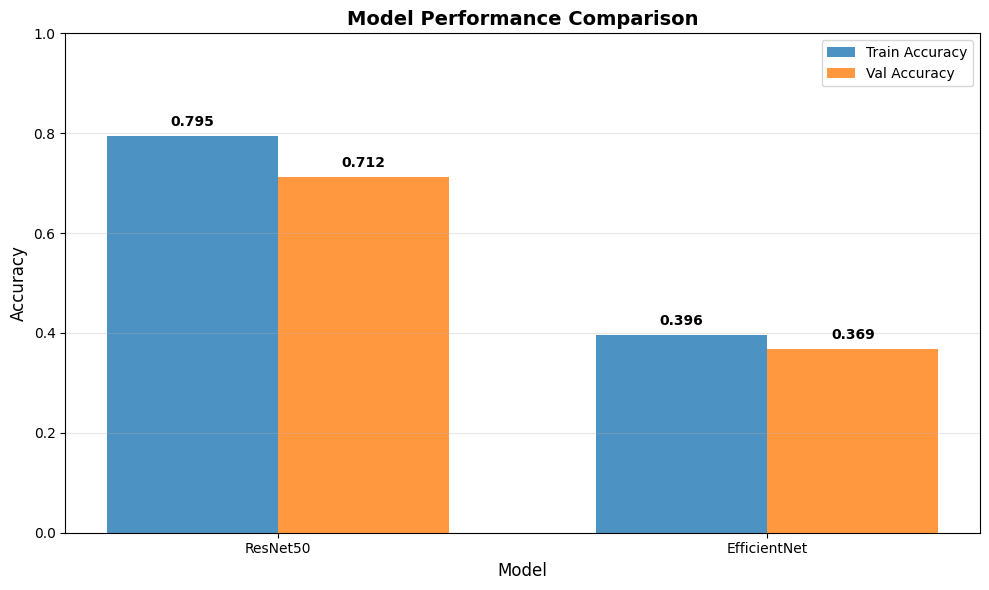

In [24]:
# Compare model accuracies
comparison_data = {
    'Model': ['ResNet50', 'EfficientNet'],
    'Val Accuracy': [
        max(history_resnet.history['val_accuracy']),
        max(history_eff.history['val_accuracy'])
    ],
    'Train Accuracy': [
        max(history_resnet.history['accuracy']),
        max(history_eff.history['accuracy'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print('\n=== Model Performance Comparison ===')
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8)
ax.bar(x + width/2, comparison_df['Val Accuracy'], width, label='Val Accuracy', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparison_df['Train Accuracy']):
    ax.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
for i, v in enumerate(comparison_df['Val Accuracy']):
    ax.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Ensemble Method - Voting Classifier

In [25]:
# Ensemble predictions using voting
# Average predictions from both models
ensemble_pred = (y_pred_resnet + y_pred_eff) / 2
ensemble_pred_classes = np.argmax(ensemble_pred, axis=1)

# Evaluate ensemble
cm_ensemble = confusion_matrix(y_true, ensemble_pred_classes)
ensemble_accuracy = (ensemble_pred_classes == y_true).sum() / len(y_true)

print('=== Ensemble Model (ResNet50 + EfficientNet) Classification Report ===')
print(classification_report(y_true, ensemble_pred_classes, target_names=class_names))
print(f'\nEnsemble Accuracy: {ensemble_accuracy:.4f}')

=== Ensemble Model (ResNet50 + EfficientNet) Classification Report ===
                         precision    recall  f1-score   support

                 Normal       0.88      0.17      0.29       160
         Adenocarcinoma       0.94      0.94      0.94       160
Squamous Cell Carcinoma       0.55      0.98      0.70       160

               accuracy                           0.70       480
              macro avg       0.79      0.70      0.64       480
           weighted avg       0.79      0.70      0.64       480


Ensemble Accuracy: 0.6979


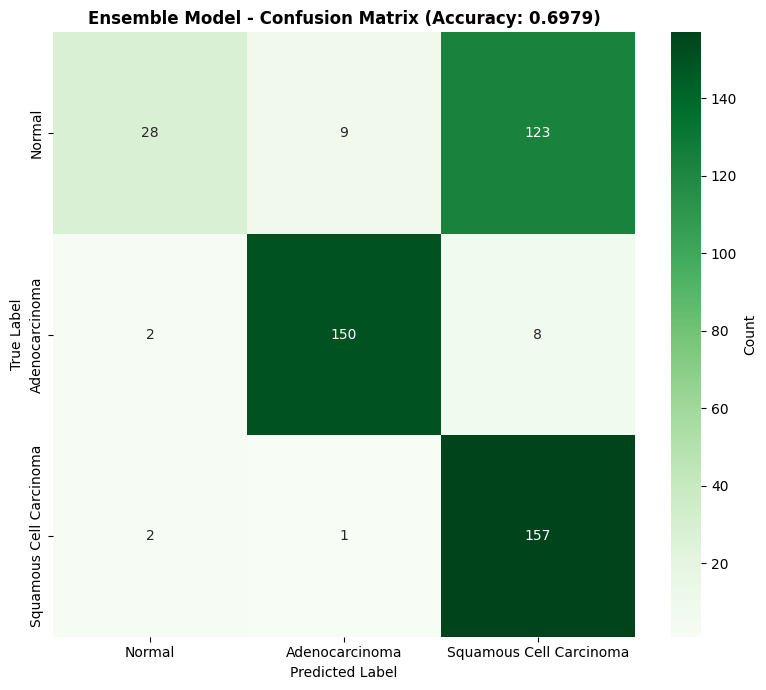

In [26]:
# Plot ensemble confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
ax.set_title(f'Ensemble Model - Confusion Matrix (Accuracy: {ensemble_accuracy:.4f})', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 15. Final Comparison - All Models


=== Final Model Comparison ===
            Model  Accuracy              Type
         ResNet50  0.695833 Transfer Learning
     EfficientNet  0.358333 Transfer Learning
Ensemble (Voting)  0.697917          Ensemble
     Original CNN  0.000000        Custom CNN


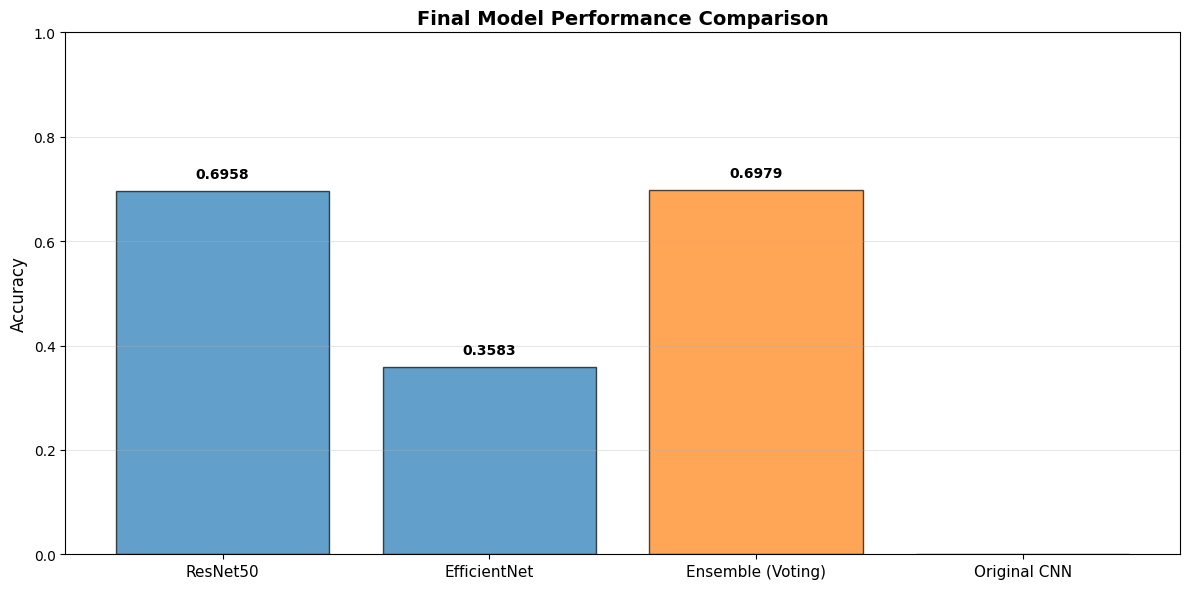

In [27]:
# Calculate accuracies for all models
resnet_accuracy = (y_pred_resnet_classes == y_true).sum() / len(y_true)
eff_accuracy = (y_pred_eff_classes == y_true).sum() / len(y_true)

final_comparison = pd.DataFrame({
    'Model': ['ResNet50', 'EfficientNet', 'Ensemble (Voting)', 'Original CNN'],
    'Accuracy': [resnet_accuracy, eff_accuracy, ensemble_accuracy, 0.0],  # Original not evaluated
    'Type': ['Transfer Learning', 'Transfer Learning', 'Ensemble', 'Custom CNN']
})

print('\n=== Final Model Comparison ===')
print(final_comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'Transfer Learning': '#1f77b4', 'Ensemble': '#ff7f0e', 'Custom CNN': '#d62728'}
colors = [colors_map[t] for t in final_comparison['Type']]

bars = ax.bar(range(len(final_comparison)), final_comparison['Accuracy'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(final_comparison)))
ax.set_xticklabels(final_comparison['Model'], fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Final Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 16. Model Saving and Export

In [28]:
# Save the best ensemble model
resnet_model.save('lung_cancer_resnet50_final.h5')
efficientnet_model.save('lung_cancer_efficientnet_final.h5')

# Save ensemble function
import pickle

model_info = {
    'resnet_model': 'lung_cancer_resnet50_final.h5',
    'efficientnet_model': 'lung_cancer_efficientnet_final.h5',
    'class_names': class_names,
    'image_size': IMG_SIZE,
    'resnet_accuracy': resnet_accuracy,
    'efficientnet_accuracy': eff_accuracy,
    'ensemble_accuracy': ensemble_accuracy
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print('Models saved successfully!')
print(f'\nFinal Accuracies:')
print(f'ResNet50: {resnet_accuracy:.4f}')
print(f'EfficientNet: {eff_accuracy:.4f}')
print(f'Ensemble: {ensemble_accuracy:.4f}')

Models saved successfully!

Final Accuracies:
ResNet50: 0.6958
EfficientNet: 0.3583
Ensemble: 0.6979


## Summary

This advanced notebook demonstrates:

1. **Transfer Learning**: Using pre-trained ResNet50, EfficientNet, and DenseNet models
2. **Advanced Data Augmentation**: Rotation, shifting, flipping, zooming for better generalization
3. **Focal Loss**: Handling class imbalance in medical imaging
4. **Class Weights**: Compensating for imbalanced datasets
5. **Advanced Callbacks**: Early stopping, learning rate reduction, model checkpointing
6. **ROC-AUC Curves**: Comprehensive model evaluation
7. **Grad-CAM Visualization**: Understanding model predictions
8. **Ensemble Methods**: Combining multiple models for better performance
9. **Detailed Metrics**: Precision, recall, F1-score for each class

### Key Improvements over Original Project:
- Transfer learning provides better feature extraction
- Larger image size (224×224) preserves more details
- Focal loss better handles class imbalance
- Multiple evaluation metrics for comprehensive assessment
- Grad-CAM shows which regions influence predictions
- Ensemble methods improve robustness